# H1 — Variable Redundancy Analysis

Pearson and Spearman correlation matrices on the variables exposed on the H1 platform site, grouped by display family:

- **Raw**: absolute counts and sums over the analysed matches
- **Per 90**: rate metrics normalised to 90 minutes
- **Percentages**: efficiency rates

**Goal**: identify pairs of variables that carry largely the same information, so we can decide whether to consolidate or keep them as complementary views.

**Source**: `data/player_space_control_aggregated.csv`, filtered to players with at least 135 minutes (1.5 matches), matching the H1 analysis pool of 272 players.

**Scope**. This is an exploratory diagnostic notebook, not a deliverable: it was used during the design of the H1 indices to inspect which variables carry overlapping information and to decide which to consolidate, which to keep as complementary views, and which to leave out of the radars. 


## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))
from src import config

df = pd.read_csv(config.PLAYER_AGG_PATH)
df = df[df['minutes_played'] >= config.ANALYSIS_MIN_MINUTES].reset_index(drop=True)
print(f'Players in pool: {len(df)}')

Players in pool: 272


In [2]:
# Variables shown on the H1 site, grouped by display family

RAW_VARS = [
    # PROGRESSION
    'lb_geom', 'lb_quality', 'lb_epv', 'defenders_bypassed_mean',
    'penetration_n', 'successful_hull_penetrations_n',
    # DANGEROUSNESS (EPV by geom_type, sums)
    'epv_penetration_sum', 'epv_inside_circ_sum',
    'epv_exit_sum', 'epv_outside_circ_sum',
    # RECEPTION (context counts)
    'between_lines_n', 'pressure_resistance_n', 'inside_circ_n',
    # GRAVITY
    'gravity_directional_m',
]

PER90_VARS = [
    # PROGRESSION
    'lb_geom_per90', 'lb_quality_per90', 'lb_epv_per90',
    'penetration_per90', 'successful_hull_penetrations_per90',
    # DANGEROUSNESS (EPV total + 4 sub-components by geom_type)
    'epv_added_per90',
    'epv_penetration_per90', 'epv_inside_circ_per90',
    'epv_exit_per90', 'epv_outside_circ_per90',
    # RECEPTION
    'between_lines_per90', 'successful_hull_exits_per90', 'inside_circ_per90',
]

PCT_VARS = [
    'lb_geom_pct', 'lb_quality_pct', 'lb_epv_pct', 'penetration_completion_pct',
    'between_lines_pct', 'hull_exit_pct', 'pressure_resistance_pct',
    'gravity_proximity_pct', 'gravity_hull_pct', 'gravity_composite_pct',
]

print(f'RAW: {len(RAW_VARS)} | PER90: {len(PER90_VARS)} | PCT: {len(PCT_VARS)}')
print(f'Total: {len(RAW_VARS) + len(PER90_VARS) + len(PCT_VARS)}')


RAW: 14 | PER90: 13 | PCT: 10
Total: 37


In [3]:
def correlations(df, vars):
    sub = df[vars].dropna()
    return sub.corr(method='pearson'), sub.corr(method='spearman')

def redundant_pairs(pear, spea, threshold=0.70):
    rows = []
    cols = pear.columns.tolist()
    for i, a in enumerate(cols):
        for b in cols[i+1:]:
            p = pear.loc[a, b]
            s = spea.loc[a, b]
            score = max(abs(p), abs(s))
            if score >= threshold:
                rows.append({'A': a, 'B': b, 'pearson': p, 'spearman': s, 'max_abs': score})
    return pd.DataFrame(rows).sort_values('max_abs', ascending=False).reset_index(drop=True)

def plot_heatmap(corr, title):
    n = len(corr)
    fig, ax = plt.subplots(figsize=(0.55*n + 3, 0.55*n + 2))
    sns.heatmap(
        corr, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.4,
        annot_kws={'size': 8}, cbar_kws={'shrink': 0.7},
        ax=ax,
    )
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    return fig

def summarise(pairs, label, n_vars):
    strong = int((pairs['max_abs'] >= 0.85).sum())
    moderate = int(((pairs['max_abs'] >= 0.70) & (pairs['max_abs'] < 0.85)).sum())
    total = n_vars * (n_vars - 1) // 2
    print(f'{label:<12s} | strong (>=0.85): {strong:3d} | moderate (0.70-0.85): {moderate:3d} | total pairs: {total:3d}')

---

## 1. RAW variables (absolute counts and sums)

Volume metrics over the analysed matches. Expected to be highly correlated with each other and with `minutes_played` simply because more time on the pitch produces more events.

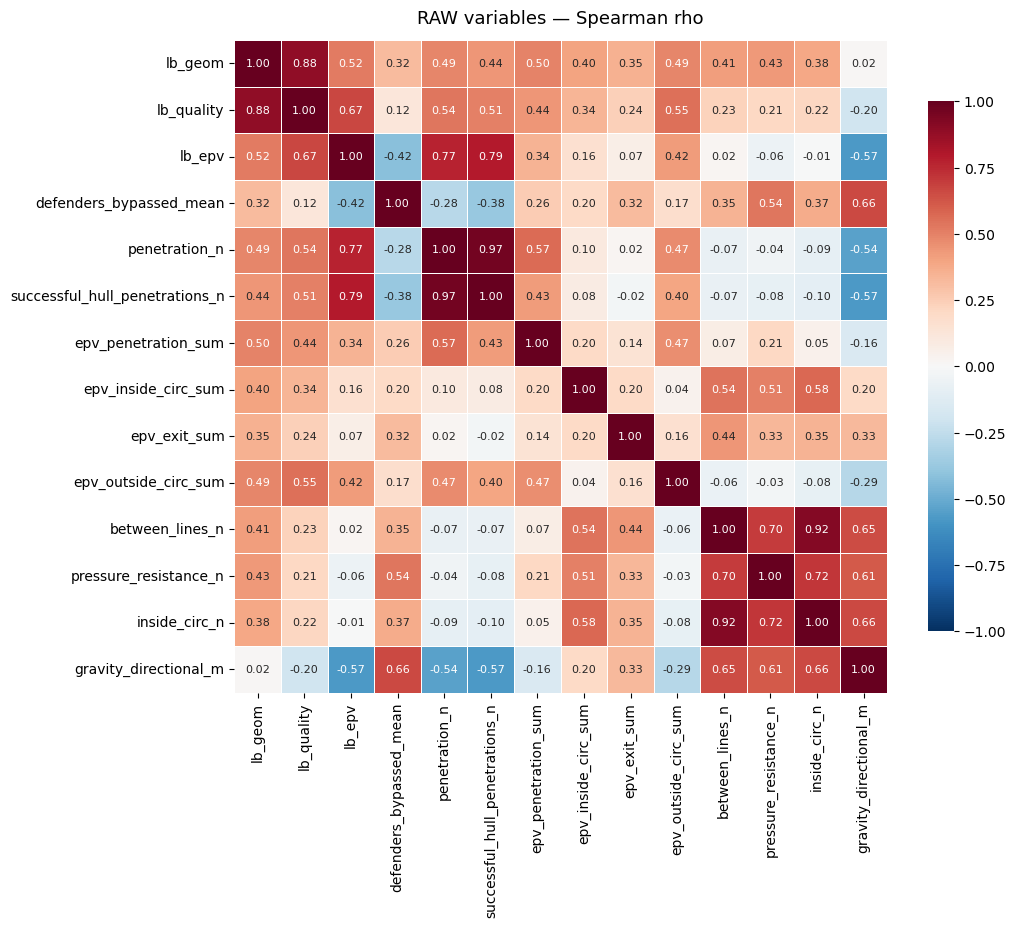

In [4]:
pear_raw, spea_raw = correlations(df, RAW_VARS)
plot_heatmap(spea_raw, 'RAW variables — Spearman rho')
plt.show()

In [5]:
pairs_raw = redundant_pairs(pear_raw, spea_raw, threshold=0.80)
summarise(pairs_raw, 'RAW', len(RAW_VARS))
pairs_raw.round(3)

RAW          | strong (>=0.85):   3 | moderate (0.70-0.85):   2 | total pairs:  91


,A,B,pearson,spearman,max_abs
0,penetration_n,successful_hull_penetrations_n,0.981,0.967,0.981
1,between_lines_n,inside_circ_n,0.920,0.915,0.920
2,lb_geom,lb_quality,0.906,0.883,0.906
3,lb_epv,successful_hull_penetrations_n,0.816,0.790,0.816
4,lb_epv,penetration_n,0.805,0.768,0.805


---

## 2. PER 90 variables (rate metrics)

Counts normalised by playing time. Removes the volume confound and exposes the underlying playing style. Most directly comparable to what feeds the radar.

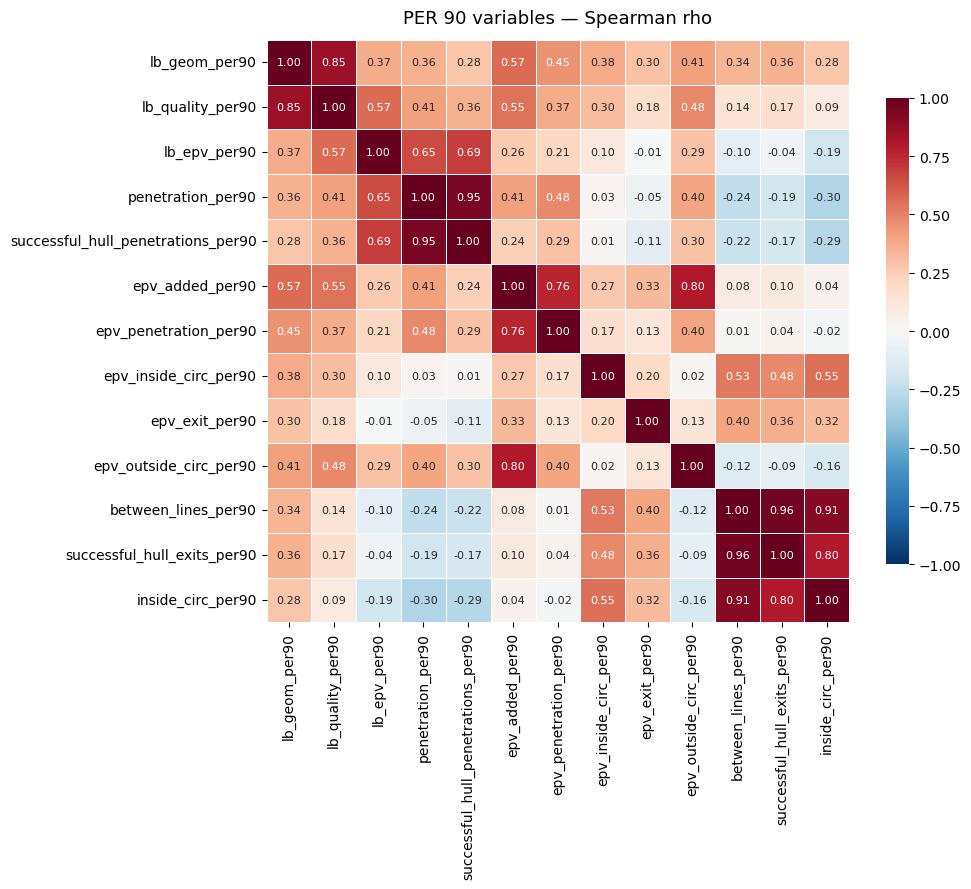

In [6]:
pear_p90, spea_p90 = correlations(df, PER90_VARS)
plot_heatmap(spea_p90, 'PER 90 variables — Spearman rho')
plt.show()

In [7]:
pairs_p90 = redundant_pairs(pear_p90, spea_p90, threshold=0.80)
summarise(pairs_p90, 'PER 90', len(PER90_VARS))
pairs_p90.round(3)

PER 90       | strong (>=0.85):   4 | moderate (0.70-0.85):   2 | total pairs:  78


,A,B,pearson,spearman,max_abs
0,between_lines_per90,successful_hull_exits_per90,0.960,0.963,0.963
1,penetration_per90,successful_hull_penetrations_per90,0.958,0.950,0.958
2,between_lines_per90,inside_circ_per90,0.883,0.907,0.907
3,lb_geom_per90,lb_quality_per90,0.854,0.852,0.854
4,epv_added_per90,epv_outside_circ_per90,0.827,0.803,0.827
5,epv_added_per90,epv_penetration_per90,0.826,0.760,0.826


---

## 3. PERCENTAGE variables (efficiency rates)

Ratios of action-type over total opportunities. Independent of volume in principle, so any redundancy here is conceptual rather than a normalisation artefact.

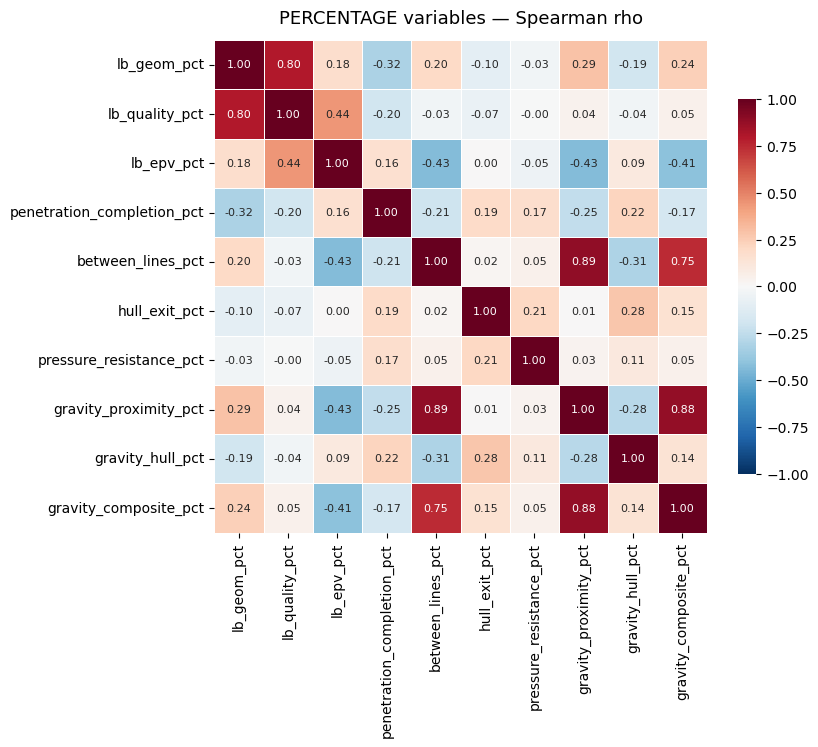

In [8]:
pear_pct, spea_pct = correlations(df, PCT_VARS)
plot_heatmap(spea_pct, 'PERCENTAGE variables — Spearman rho')
plt.show()

In [9]:
pairs_pct = redundant_pairs(pear_pct, spea_pct, threshold=0.80)
summarise(pairs_pct, 'PCT', len(PCT_VARS))
pairs_pct.round(3)

PCT          | strong (>=0.85):   2 | moderate (0.70-0.85):   0 | total pairs:  45


,A,B,pearson,spearman,max_abs
0,gravity_proximity_pct,gravity_composite_pct,0.920,0.875,0.920
1,between_lines_pct,gravity_proximity_pct,0.848,0.887,0.887


---

## Cross-group summary

Compact view of redundancy load across the three families.

In [10]:
print('Group         | strong (>=0.85)  moderate (0.70-0.85)  total pairs')
print('-' * 70)
summarise(pairs_raw, 'RAW',    len(RAW_VARS))
summarise(pairs_p90, 'PER 90', len(PER90_VARS))
summarise(pairs_pct, 'PCT',    len(PCT_VARS))

Group         | strong (>=0.85)  moderate (0.70-0.85)  total pairs
----------------------------------------------------------------------
RAW          | strong (>=0.85):   3 | moderate (0.70-0.85):   2 | total pairs:  91
PER 90       | strong (>=0.85):   4 | moderate (0.70-0.85):   2 | total pairs:  78
PCT          | strong (>=0.85):   2 | moderate (0.70-0.85):   0 | total pairs:  45


---

### Interesting findings from the correlation analysis

1. **`between_lines_pct` ↔ `gravity_proximity_pct` (ρ ≈ 0.91, r ≈ 0.85)** is the only strong correlation in the percentage block that is **not** structural or tautological. It says players who frequently receive between the opposing lines are also the ones who, on average, draw the nearest defenders closest to them when they have the ball. The two metrics live in different sections of the radar (RECEPTION vs GRAVITY), so the finding is genuine rather than a redundancy: being a "between lines receiver" and being a "magnet for nearby defenders" are empirically the same player profile in this dataset. Worth citing as a substantive observation in the H1 narrative, not as a redundancy to resolve.

2. **`epv_added_per90` correlates ≥0.80 with its largest sub-components** (notably `epv_outside_circ_per90`, ρ ≈ 0.80, and `epv_penetration_per90`, ρ ≈ 0.76 with Pearson 0.83). This is **structural and intended**, not a redundancy to remove: `epv_added_per90` is by construction the sum of the four EPV sub-components by geom_type, so high totals are partly produced by high values on each axis. The DANGEROUSNESS index treats this explicitly: `epv_added_per90` feeds the headline number (magnitude), while the four sub-components form the radar (profile), and the two layers are kept separate by design. Reading the correlation in the table without that context could suggest a redundancy that does not exist analytically.

3. **`between_lines_per90` ↔ `inside_circ_per90` (ρ ≈ 0.91)** is also expected and not a problem: `inside_circ_per90` is by construction a subset of the in→in passes counted inside `between_lines_per90`. The two are kept on the site because `inside_circ_per90` is a contextual stat under RECEPTION (not a radar axis), so the correlation does not affect any index calculation.

